# Noise-aware WRPGA: revised, reproducible experiments
**Companion to `v02.tex` — revision of 25 September 2026.**

Run all cells in order with Python 3. The notebook regenerates every experimental figure, CSV and LaTeX table used by the revised manuscript. Files are written into `figures/` and `results/` relative to the working directory. No network access is used.

Dependencies: NumPy, SciPy, pandas, Matplotlib and threadpoolctl. In Jupyter, install these in the selected kernel environment if needed. Exact versions from the supplied execution are saved in `results/environment.json`; numerical comparisons use tolerances, and runtimes remain hardware dependent.

This revision fixes the iteration-limit error, implements genuinely weak selection, records stopping reasons, uses spanning overcomplete dictionaries for the sparse experiments, and compares with incremental-QR OMP. Old experimental numbers and figures are replaced, not silently reused.

## Mathematical quantities
For $L=1-(s-1)\mu>0$, set $A=\sqrt{L/s}$ and $\beta=s\mu/L$. When $t>\beta$, a support-safe threshold is
$\vartheta\ge(1+\beta)/(t-\beta)$. We add a margin of $0.5$. The improved beta-min condition is $a_{\min}/\delta>(\vartheta+1)/L$.

The general atomic correlation threshold is $q=\kappa(\kappa-1)\delta^2/B$. Its two-phase bound is
$\lceil4B^2/(t^2\delta^2)\rceil+\lceil2B^2/(t^2\kappa^2(\kappa-1)^2\delta^2)\rceil-1$.

Random or deliberately directed noise always has Euclidean norm exactly $\delta$ (up to roundoff). Directed noise points towards the off-support atom most correlated with the clean signal; it is a stress test, not a certified worst-case adversary.

In [1]:
from pathlib import Path
import json, platform, sys, time, hashlib
import numpy as np
import scipy
from scipy.linalg import hadamard, solve_triangular
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from threadpoolctl import threadpool_limits, threadpool_info

SEED = 20260925
FIG = Path('figures'); DATA = Path('results')
FIG.mkdir(exist_ok=True); DATA.mkdir(exist_ok=True)
plt.rcParams.update({'figure.figsize': (6.6, 4.2), 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})
environment = {'python': sys.version, 'platform': platform.platform(),
               'machine': platform.machine(), 'processor': platform.processor(),
               'numpy': np.__version__, 'scipy': scipy.__version__,
               'pandas': pd.__version__, 'matplotlib': matplotlib.__version__,
               'seed': SEED, 'blas_threads_in_experiments': 1,
               'threadpools': threadpool_info()}
(DATA / 'environment.json').write_text(json.dumps(environment, indent=2))
print({k: environment[k] for k in ['numpy','scipy','pandas','matplotlib','seed']})

def savefig(name):
    fig = plt.gcf(); fig.tight_layout()
    fig.savefig(FIG / (name + '.pdf'), bbox_inches='tight')
    fig.savefig(FIG / (name + '.png'), dpi=180, bbox_inches='tight')
    plt.show()
    plt.close(fig)

def coherence(D):
    G = D.T @ D
    np.fill_diagonal(G, 0)
    return float(np.max(np.abs(G)))

def redundant_dictionary(n=128):
    # I and normalized Sylvester Hadamard are orthonormal bases of R^n.
    D = np.column_stack((np.eye(n), hadamard(n) / np.sqrt(n)))
    assert np.allclose(np.linalg.norm(D, axis=0), 1)
    assert np.linalg.matrix_rank(D) == n
    assert np.isclose(coherence(D), 1/np.sqrt(n))
    return D

def constants(s, mu, t=1.0):
    L = 1 - (s-1)*mu
    if L <= 0:
        raise ValueError('Need L > 0.')
    A = np.sqrt(L/s); beta = s*mu/L
    if t <= beta:
        raise ValueError('Need t > beta for the support theorem.')
    theta_min = (1+beta)/(t-beta)
    theta = theta_min + 0.5
    return dict(L=L, A=A, beta=beta, theta_min=theta_min,
                theta=theta, rho=1-t*t*A*A, beta_min=(theta+1)/L)

def noisy(clean, delta, rng, D=None, S=None, mode='random'):
    if mode == 'random':
        z = rng.normal(size=clean.size)
    elif mode == 'directed':
        corr = D.T @ clean
        scores = np.abs(corr); scores[np.asarray(S)] = -np.inf
        j = int(np.argmax(scores))
        z = D[:, j] * (1 if corr[j] >= 0 else -1)
    else:
        raise ValueError('Unknown noise mode.')
    eta = delta * z / np.linalg.norm(z)
    assert np.isclose(np.linalg.norm(eta), delta, rtol=1e-12, atol=1e-14)
    return clean + eta, eta

{'numpy': '2.3.5', 'scipy': '1.17.0', 'pandas': '2.2.3', 'matplotlib': '3.10.8', 'seed': 20260925}


## Algorithms and boundary checks
`D=None` means the orthonormal identity dictionary, evaluated without forming a dense identity matrix. A matrix stores one representative of each atom up to sign; absolute correlations implement its symmetric completion.

WRPGA and PGA accept a constant weakness `t`. For `t<1`, selection is uniform over all atoms satisfying the weak condition, using an explicit seeded generator. This implementation computes the full correlation vector to verify the condition; no search-cost saving is claimed.

OMP uses exact selection and an incrementally maintained QR factorization, with reorthogonalization and triangular coefficient solves. The limit is checked **before** an update, and all histories include the returned final state. `max_iter` and `stagnation` are failures to attain the requested stopping rule, not successful stops.

In [2]:
def greedy(f, D=None, method='wrpga', t=1.0, rng=None,
           delta=0.0, kappa=None, corr_threshold=None, max_iter=10000):
    f = np.asarray(f, dtype=float)
    if method not in ('wrpga', 'pga', 'omp'):
        raise ValueError('Unknown method.')
    if not (0 < t <= 1) or max_iter < 0 or int(max_iter) != max_iter:
        raise ValueError('Invalid weakness or iteration limit.')
    if method == 'omp' and t != 1:
        raise ValueError('This OMP baseline uses exact selection.')
    if delta < 0 or (kappa is not None and kappa <= 1):
        raise ValueError('Invalid noise level or discrepancy factor.')
    if corr_threshold is not None and corr_threshold < 0:
        raise ValueError('Correlation threshold must be nonnegative.')
    if t < 1 and rng is None:
        raise ValueError('Supply an explicit generator for weak selection.')
    n = f.size; p = n if D is None else D.shape[1]
    if D is not None and D.shape[0] != n:
        raise ValueError('Dimension mismatch.')
    u = np.zeros(n); alpha = np.zeros(p)
    selected = []; states = []; history = []; lambdas = []; ratios = []
    Q = np.empty((n, 0)); R = np.empty((0, 0)); active = []
    for m in range(int(max_iter)+1):
        r = f-u
        corr = r.copy() if D is None else D.T @ r
        nu = float(np.max(np.abs(corr)))
        rn = float(np.linalg.norm(r))
        states.append(u.copy()); history.append((m, rn, nu))
        if kappa is not None and rn <= kappa*delta:
            reason = 'residual'; break
        if corr_threshold is not None and nu <= corr_threshold:
            reason = 'correlation'; break
        if rn == 0:
            reason = 'exact'; break
        if m == max_iter:
            reason = 'max_iter'; break
        if nu == 0:
            reason = 'stagnation'; break
        if method == 'omp':
            score = np.abs(corr).copy()
            score[active] = -np.inf
            j = int(np.argmax(score))
            if not np.isfinite(score[j]) or score[j] <= 1e-14*max(1.0, rn):
                reason = 'stagnation'; break
        elif t == 1:
            j = int(np.argmax(np.abs(corr)))
        else:
            eligible = np.flatnonzero(np.abs(corr) >= t*nu)
            j = int(rng.choice(eligible))
        atom = np.eye(1, n, j).ravel() if D is None else D[:, j]
        lam = float(corr[j]); ratios.append(abs(lam)/nu); lambdas.append(lam)
        selected.append(j)
        if method == 'omp':
            v = atom.copy(); a = Q.T @ v
            v -= Q @ a
            correction = Q.T @ v
            v -= Q @ correction; a += correction
            b = np.linalg.norm(v)
            if b <= 1e-12:
                raise RuntimeError('Numerically dependent OMP atom.')
            k = len(active)
            newR = np.zeros((k+1, k+1)); newR[:k,:k] = R
            newR[:k,k] = a; newR[k,k] = b
            R = newR; Q = np.column_stack((Q, v/b)); active.append(j)
            coef = solve_triangular(R, Q.T @ f)
            alpha[:] = 0; alpha[active] = coef
            u = Q @ (Q.T @ f)
        else:
            alpha[j] += lam
            uhat = u + lam*atom
            if method == 'wrpga':
                den = float(uhat @ uhat)
                sm = float(f @ uhat)/den if den > 0 else 0.0
                u = sm*uhat; alpha *= sm
            else:
                u = uhat
    return dict(u=u, residual=f-u, alpha=alpha, selected=selected,
                iterations=len(selected), stop_reason=reason,
                history=np.asarray(history), iterates=np.asarray(states),
                lambdas=np.asarray(lambdas), selection_ratios=np.asarray(ratios))

def check_run(out, f, D=None, method='wrpga', t=1.0):
    hist = out['history']; m = out['iterations']
    assert len(out['selected']) == m and len(hist) == m+1
    assert int(hist[-1,0]) == m
    assert np.allclose(out['iterates'][-1], out['u'])
    recon = out['alpha'] if D is None else D @ out['alpha']
    assert np.allclose(out['u'], recon, atol=1e-9, rtol=1e-9)
    tol = 1e-10*max(1., np.linalg.norm(f)**2)
    assert np.all(np.diff(hist[:,1]**2) <= tol)
    if m:
        assert np.min(out['selection_ratios']) >= t-1e-10
        assert np.all(hist[1:,1]**2 <= hist[:-1,1]**2-out['lambdas']**2+tol)
    if method == 'wrpga':
        orth = np.einsum('ij,ij->i', f-out['iterates'], out['iterates'])
        assert np.max(np.abs(orth)) <= tol

def succeeded(out):
    return out['stop_reason'] in ('residual','correlation','exact')

for alg in ('wrpga','pga','omp'):
    z = greedy(np.array([1., .5]), method=alg, max_iter=0)
    assert z['iterations'] == 0 and not z['selected'] and np.all(z['u']==0)
    one = greedy(np.array([1., .5]), method=alg, max_iter=1)
    assert one['iterations'] == 1 and one['stop_reason']=='max_iter'
    zero = greedy(np.zeros(2), method=alg, delta=.1, kappa=1.2)
    assert zero['iterations']==0 and zero['stop_reason']=='residual'
    check_run(one, np.array([1., .5]), method=alg)
D = redundant_dictionary(128)
S = np.array([0, 1, 128+2, 128+3])
assert np.max(np.abs(D[:,S].T@D[:,S]-np.eye(4))) > .08
print('Boundary, descent and spanning-dictionary checks passed.')
print('Dictionary shape:', D.shape, 'rank:', np.linalg.matrix_rank(D), 'mu:', coherence(D))

Boundary, descent and spanning-dictionary checks passed.
Dictionary shape: (128, 256) rank: 128 mu: 0.08838834764831843


## Experiment 1 — General atomic stopping
The identity dictionary is a baseline, not evidence that rescaling improves orthogonal approximation. The clean coefficients are $c_j=1/j$ in dimension 1024; $B=\sum_j|c_j|$ is an exact atomic norm. Weakness is $t=0.8$, $\kappa=1.2$, with 20 trials at each of five noise levels.

Both residual and general-correlation rules are tested on paired observations. Report means **and maxima**, stopping reasons and deterministic-bound violations. Finite-dimensional saturation prevents interpreting the plot as an asymptotic rate estimate.

              rule  delta  mean_iterations  max_iterations  mean_error  max_error  failures  violations
atomic-correlation 0.0125          1023.95            1024    1.000000   1.000003         0           0
atomic-correlation 0.0250          1021.45            1024    1.000007   1.000061         0           0
atomic-correlation 0.0500          1009.40            1016    1.000010   1.000277         0           0
atomic-correlation 0.1000           975.85             988    0.999975   1.000279         0           0
atomic-correlation 0.2000           906.65             923    0.999756   1.000371         0           0
          residual 0.0125           790.35             798    1.744457   1.765918         0           0
          residual 0.0250           524.20             543    1.582598   1.619268         0           0
          residual 0.0500           282.10             302    1.309068   1.333730         0           0
          residual 0.1000           125.35             139    1.

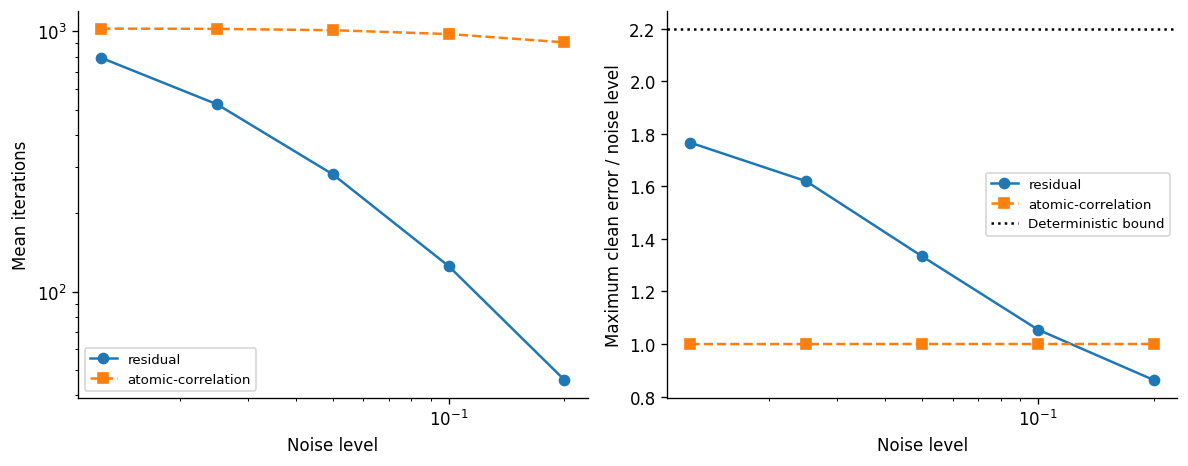

In [3]:
rows=[]
n=1024; clean=1/np.arange(1,n+1,dtype=float); B=float(np.sum(np.abs(clean)))
t=.8; kappa=1.2; c=kappa*(kappa-1)
with threadpool_limits(limits=1):
    for di, delta in enumerate([.2,.1,.05,.025,.0125]):
        for trial in range(20):
            rg=np.random.default_rng(np.random.SeedSequence([SEED,1,di,trial]))
            f,_=noisy(clean,delta,rg)
            for rule in ('residual','atomic-correlation'):
                q=c*delta**2/B
                kwargs={'kappa':kappa} if rule=='residual' else {'corr_threshold':q}
                sel=np.random.default_rng(np.random.SeedSequence([SEED,11,di,trial]))
                out=greedy(f,t=t,rng=sel,delta=delta,max_iter=2*n,**kwargs)
                check_run(out,f,t=t)
                error=float(np.linalg.norm(clean-out['u'])/delta)
                bound=int(np.ceil(4*B*B/(t*t*delta*delta)))
                if rule=='residual': bound=int(np.ceil(4*B*B/((kappa*kappa-1)*t*t*delta*delta)))
                else: bound+=int(np.ceil(2*B*B/(t*t*c*c*delta*delta)))-1
                rows.append(dict(delta=delta,trial=trial,rule=rule,iterations=out['iterations'],
                                 normalized_error=error,stop_reason=out['stop_reason'],
                                 success=succeeded(out),bound=bound,
                                 bound_violation=error>1+kappa+1e-9))
atomic_df=pd.DataFrame(rows)
assert atomic_df.success.all() and not atomic_df.bound_violation.any()
atomic_summary=atomic_df.groupby(['rule','delta'],as_index=False).agg(
    mean_iterations=('iterations','mean'),max_iterations=('iterations','max'),
    mean_error=('normalized_error','mean'),max_error=('normalized_error','max'),
    failures=('success',lambda x: int((~x).sum())),violations=('bound_violation','sum'))
atomic_df.to_csv(DATA/'atomic_trials.csv',index=False)
atomic_summary.to_csv(DATA/'atomic_summary.csv',index=False)
print(atomic_summary.to_string(index=False))
fig,axs=plt.subplots(1,2,figsize=(10,4))
for label,style in [('residual','o-'),('atomic-correlation','s--')]:
    d=atomic_summary[atomic_summary.rule==label]
    axs[0].loglog(d.delta,d.mean_iterations,style,label=label)
    axs[1].semilogx(d.delta,d.max_error,style,label=label)
axs[0].set(xlabel='Noise level',ylabel='Mean iterations')
axs[1].axhline(1+kappa,color='black',linestyle=':',label='Deterministic bound')
axs[1].set(xlabel='Noise level',ylabel='Maximum clean error / noise level')
for ax in axs: ax.legend(fontsize=8)
savefig('fig_general_stopping')

## Experiment 2 — Nonorthogonal support, weak selection and geometric contraction
Use $D=[I_{128},H_{128}/\sqrt{128}]$, a spanning overcomplete dictionary with 256 atoms, and a mixed support of four atoms. Cross-block inner products have magnitude $1/\sqrt{128}$, so the support is not orthogonal.

For $t=1$ and $t=0.8$, use the improved safe threshold plus 0.5. Seven positive noise levels, 20 trials per level and two noise directions are tested. Projection onto the true support is used **only for auditing** the contraction and iteration bound, never in WRPGA.

Support-theorem trials: 560 failures: 0
     min_ratio  mean_repeats  max_error
t                                      
0.8   0.800251      3.910714   9.494098
1.0   1.000000      4.353571   5.380069
Constants: {'1.0': {'L': 0.7348349570550448, 'A': np.float64(0.428612574784923), 'beta': 0.4811330587894036, 'theta_min': 2.854552759390861, 'theta': 3.354552759390861, 'rho': np.float64(0.8162912607362388), 'beta_min': 5.925892225980033}, '0.8': {'L': 0.7348349570550448, 'A': np.float64(0.428612574784923), 'beta': 0.4811330587894036, 'theta_min': 4.644987822087162, 'theta': 5.144987822087162, 'rho': np.float64(0.8824264068711928), 'beta_min': 8.362405412385487}}


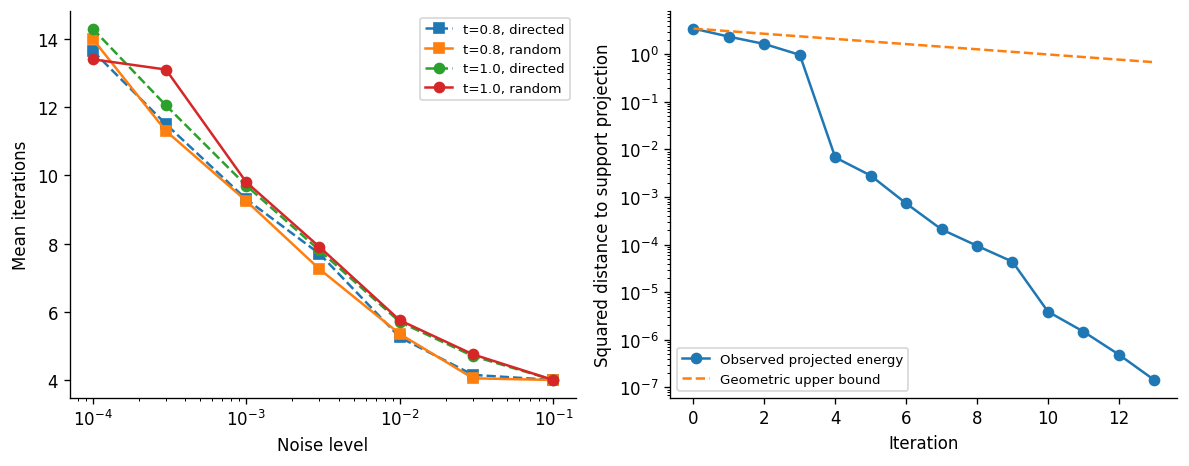

In [4]:
D=redundant_dictionary(128); mu=coherence(D)
S=np.array([0,1,130,131]); s=len(S); Qs,_=np.linalg.qr(D[:,S])
rows=[]; trace=None
with threadpool_limits(limits=1):
    for ti,t in enumerate([1.,.8]):
        const=constants(s,mu,t)
        for di,delta in enumerate([.1,.03,.01,.003,.001,.0003,.0001]):
            for modei,mode in enumerate(['random','directed']):
                for trial in range(20):
                    rg=np.random.default_rng(np.random.SeedSequence([SEED,2,ti,di,modei,trial]))
                    amps=rg.uniform(.8,1.2,size=s)*rg.choice([-1.,1.],size=s)
                    clean=D[:,S]@amps
                    f,_=noisy(clean,delta,rg,D,S,mode)
                    out=greedy(f,D,t=t,rng=rg,delta=delta,
                               corr_threshold=const['theta']*delta,max_iter=5000)
                    check_run(out,f,D,t=t)
                    p=Qs@(Qs.T@f)
                    E=np.sum((out['iterates']-p)**2,axis=1)
                    tolerance=1e-10*max(1.,np.linalg.norm(f)**2)
                    contraction=bool(np.all(E[1:]<=const['rho']*E[:-1]+tolerance))
                    ratio=np.linalg.norm(p)**2/((const['theta']-1)**2*delta**2)
                    log_bound=max(0,int(np.ceil(np.log(ratio)/(-np.log(const['rho'])))))
                    selected=set(out['selected']); false=bool(selected-set(S))
                    error=float(np.linalg.norm(clean-out['u'])/delta)
                    beta_holds=np.min(np.abs(amps))/delta>const['beta_min']
                    covered=set(S).issubset(selected)
                    rows.append(dict(t=t,delta=delta,mode=mode,trial=trial,
                       iterations=out['iterations'],repeats=out['iterations']-len(selected),
                       normalized_error=error,false_selection=false,full_support=covered,
                       beta_holds=beta_holds,theta=const['theta'],log_bound=log_bound,
                       contraction_ok=contraction,stop_reason=out['stop_reason'],success=succeeded(out),
                       min_selection_ratio=float(np.min(out['selection_ratios'])) if out['iterations'] else 1.,
                       error_violation=error>(const['theta']+1)/const['A']+1e-8))
                    if t==.8 and delta==.0001 and mode=='directed' and trial==0:
                        trace=(E.copy(),const['rho'],out['history'].copy())
sparse_df=pd.DataFrame(rows)
assert sparse_df.success.all() and sparse_df.contraction_ok.all()
assert not sparse_df.false_selection.any() and not sparse_df.error_violation.any()
assert (sparse_df.iterations<=sparse_df.log_bound).all()
assert sparse_df.loc[sparse_df.beta_holds,'full_support'].all()
sparse_summary=sparse_df.groupby(['t','delta','mode'],as_index=False).agg(
    mean_iterations=('iterations','mean'),max_iterations=('iterations','max'),
    mean_repeats=('repeats','mean'),max_error=('normalized_error','max'),
    false_rate=('false_selection','mean'),coverage=('full_support','mean'),
    max_log_bound=('log_bound','max'))
sparse_df.to_csv(DATA/'sparse_trials.csv',index=False)
sparse_summary.to_csv(DATA/'sparse_summary.csv',index=False)
print('Support-theorem trials:',len(sparse_df),'failures:',int((~sparse_df.success).sum()))
print(sparse_df.groupby('t').agg(min_ratio=('min_selection_ratio','min'),
     mean_repeats=('repeats','mean'),max_error=('normalized_error','max')).to_string())
print('Constants:',{str(t):constants(s,mu,t) for t in [1.,.8]})
fig,axs=plt.subplots(1,2,figsize=(10,4))
for (t,mode),d in sparse_summary.groupby(['t','mode']):
    axs[0].semilogx(d.delta,d.mean_iterations,marker='o' if t==1 else 's',
                    linestyle='-' if mode=='random' else '--',label=f't={t}, {mode}')
E,rho,hist=trace
axs[1].semilogy(np.arange(len(E)),np.maximum(E,1e-30),'o-',label='Observed projected energy')
axs[1].semilogy(np.arange(len(E)),E[0]*rho**np.arange(len(E)),'--',label='Geometric upper bound')
axs[0].set(xlabel='Noise level',ylabel='Mean iterations')
axs[1].set(xlabel='Iteration',ylabel='Squared distance to support projection')
for ax in axs:ax.legend(fontsize=8)
savefig('fig_sparse_contraction')

## Experiment 3 — Improved beta-min bound
Use the same mixed support and dictionary, $t=0.8$, $\delta=0.02$. In each trial **one coefficient has magnitude exactly `amin`**, so the horizontal axis is the realized minimum, not merely a lower bound. The other magnitudes lie in $[a_{\min},1.25a_{\min}]$. There are 40 trials per ratio and noise direction.

Improved sufficient beta-min ratio: 8.362405412385487
 ratio     mode  coverage  false_rate  max_error
   0.5 directed       0.0         0.0   1.200700
   0.5   random       0.0         0.0   1.191453
   1.0 directed       0.0         0.0   2.457636
   1.0   random       0.0         0.0   2.416598
   2.0 directed       0.0         0.0   4.728302
   2.0   random       0.0         0.0   4.871694
   3.0 directed       0.0         0.0   7.163451
   3.0   random       0.0         0.0   7.068668
   4.0 directed       0.0         0.0   9.221274
   4.0   random       0.0         0.0   9.149720
   6.0 directed       1.0         0.0   1.323514
   6.0   random       1.0         0.0   1.498581
   8.0 directed       1.0         0.0   1.885282
   8.0   random       1.0         0.0   1.854684
  10.0 directed       1.0         0.0   2.393455
  10.0   random       1.0         0.0   2.281286
  12.0 directed       1.0         0.0   2.878520
  12.0   random       1.0         0.0   2.826100


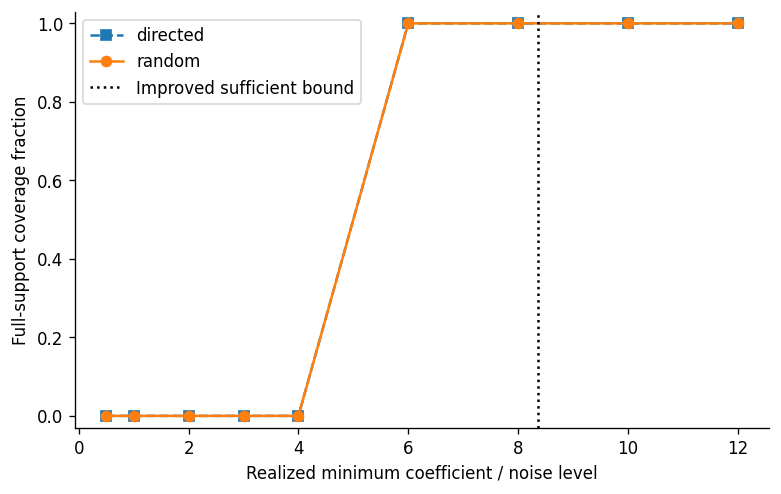

In [5]:
t=.8; delta=.02; const=constants(4,mu,t); rows=[]
with threadpool_limits(limits=1):
    for ri,ratio in enumerate([.5,1,2,3,4,6,8,10,12]):
        for modei,mode in enumerate(['random','directed']):
            for trial in range(40):
                rg=np.random.default_rng(np.random.SeedSequence([SEED,3,ri,modei,trial]))
                mags=ratio*delta*rg.uniform(1,1.25,size=4);mags[0]=ratio*delta
                amps=mags*rg.choice([-1.,1.],size=4)
                assert np.isclose(np.min(np.abs(amps))/delta,ratio)
                clean=D[:,S]@amps;f,_=noisy(clean,delta,rg,D,S,mode)
                out=greedy(f,D,t=t,rng=rg,delta=delta,
                           corr_threshold=const['theta']*delta,max_iter=3000)
                check_run(out,f,D,t=t)
                selected=set(out['selected'])
                rows.append(dict(ratio=ratio,mode=mode,trial=trial,
                    full_support=set(S).issubset(selected),false_selection=bool(selected-set(S)),
                    stop_reason=out['stop_reason'],success=succeeded(out),
                    normalized_error=float(np.linalg.norm(clean-out['u'])/delta)))
beta_df=pd.DataFrame(rows)
assert beta_df.success.all() and not beta_df.false_selection.any()
assert beta_df.loc[beta_df.ratio>const['beta_min'],'full_support'].all()
beta_summary=beta_df.groupby(['ratio','mode'],as_index=False).agg(
    coverage=('full_support','mean'),false_rate=('false_selection','mean'),
    max_error=('normalized_error','max'))
beta_df.to_csv(DATA/'beta_trials.csv',index=False)
beta_summary.to_csv(DATA/'beta_summary.csv',index=False)
print('Improved sufficient beta-min ratio:',const['beta_min'])
print(beta_summary.to_string(index=False))
for mode,d in beta_summary.groupby('mode'):
    plt.plot(d.ratio,d.coverage,'o-' if mode=='random' else 's--',label=mode)
plt.axvline(const['beta_min'],color='black',ls=':',label='Improved sufficient bound')
plt.ylim(-.03,1.03);plt.xlabel('Realized minimum coefficient / noise level')
plt.ylabel('Full-support coverage fraction');plt.legend()
savefig('fig_beta_min')

## Experiment 4 — WRPGA, PGA and incremental-QR OMP
A larger spanning dictionary $[I_{512},H_{512}/\sqrt{512}]$ is used, with eight support atoms split equally between its two blocks. On 20 paired observations, each method is run with both residual and support-correlation stopping, using $t=1$, $\delta=0.01$ and $\kappa=1.2$.

Timed method order is randomized and every method is warmed up; BLAS is restricted to one thread. Record mean and median wall-clock time. Different stopping rules can deliver different accuracies: runtime alone is not a comparison at equal error. No claim is made that these small-scale timings represent optimized implementations.

Comparison theta: 3.5976957211411573
method        rule  mean_iterations  mean_seconds  median_seconds  mean_error  max_error  false_rate  coverage
   OMP correlation             8.00      0.001243        0.001189    0.105502   0.172139         0.0       1.0
   OMP    residual             8.00      0.001204        0.001177    0.105502   0.172139         0.0       1.0
   PGA correlation            12.90      0.001176        0.001181    2.184452   4.199063         0.0       1.0
   PGA    residual            15.80      0.001398        0.001349    0.478382   0.673661         0.0       1.0
 WRPGA correlation            12.10      0.001166        0.001153    4.501095   6.080561         0.0       1.0
 WRPGA    residual            18.65      0.001704        0.001706    0.587571   0.701500         0.0       1.0


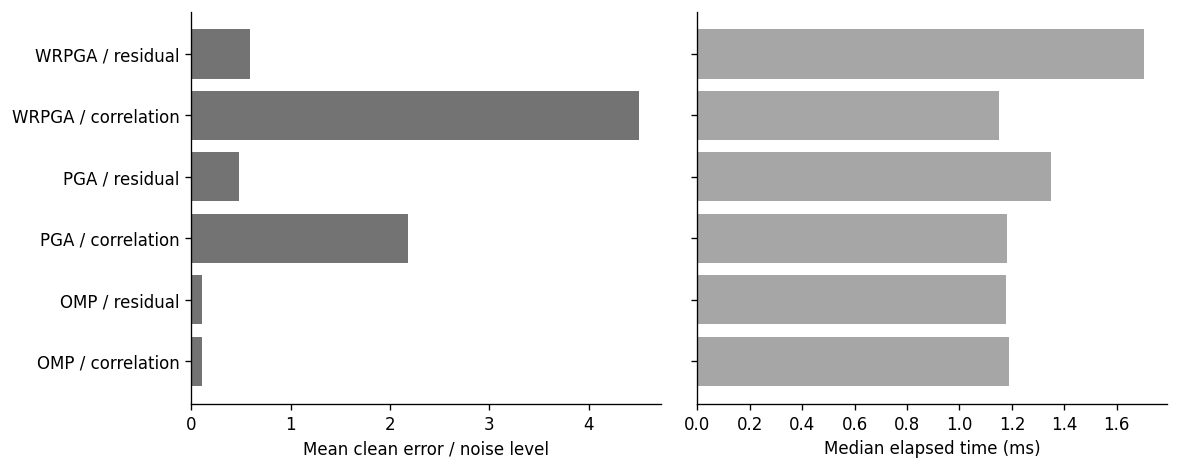

In [6]:
Dc=redundant_dictionary(512); Sc=np.array([0,1,2,3,516,517,518,519])
cc=constants(8,coherence(Dc),1.);delta=.01;kappa=1.2
methods=[(method,rule) for method in ['wrpga','pga','omp'] for rule in ['residual','correlation']]
rows=[]
with threadpool_limits(limits=1):
    warm_f=Dc[:,Sc]@np.ones(8)
    for method,rule in methods:
        kwargs={'kappa':kappa} if rule=='residual' else {'corr_threshold':cc['theta']*delta}
        greedy(warm_f,Dc,method=method,delta=delta,max_iter=3000,**kwargs)
    for trial in range(20):
        rg=np.random.default_rng(np.random.SeedSequence([SEED,4,trial]))
        amps=rg.uniform(1,2,size=8)*rg.choice([-1.,1.],size=8)
        clean=Dc[:,Sc]@amps;f,_=noisy(clean,delta,rg)
        for k in rg.permutation(len(methods)):
            method,rule=methods[k]
            kwargs={'kappa':kappa} if rule=='residual' else {'corr_threshold':cc['theta']*delta}
            start=time.perf_counter()
            out=greedy(f,Dc,method=method,delta=delta,max_iter=3000,**kwargs)
            elapsed=time.perf_counter()-start
            check_run(out,f,Dc,method=method)
            selected=set(out['selected'])
            rows.append(dict(method=method.upper(),rule=rule,trial=trial,
                iterations=out['iterations'],runtime_seconds=elapsed,
                normalized_error=float(np.linalg.norm(clean-out['u'])/delta),
                false_selection=bool(selected-set(Sc)),full_support=set(Sc).issubset(selected),
                success=succeeded(out),stop_reason=out['stop_reason']))
comp_df=pd.DataFrame(rows)
assert comp_df.success.all()
comp_summary=comp_df.groupby(['method','rule'],as_index=False).agg(
    mean_iterations=('iterations','mean'),mean_seconds=('runtime_seconds','mean'),
    median_seconds=('runtime_seconds','median'),mean_error=('normalized_error','mean'),
    max_error=('normalized_error','max'),false_rate=('false_selection','mean'),
    coverage=('full_support','mean'))
comp_df.to_csv(DATA/'comparison_trials.csv',index=False)
comp_summary.to_csv(DATA/'comparison_summary.csv',index=False)
print('Comparison theta:',cc['theta'])
print(comp_summary.to_string(index=False))
fig,axs=plt.subplots(1,2,figsize=(10,4))
labels=comp_summary['method']+' / '+comp_summary['rule']
y=np.arange(len(labels))
axs[0].barh(y,comp_summary.mean_error,color='.45');axs[0].set_yticks(y,labels)
axs[0].set_xlabel('Mean clean error / noise level')
axs[1].barh(y,1000*comp_summary.median_seconds,color='.65');axs[1].set_yticks(y,[])
axs[1].set_xlabel('Median elapsed time (ms)')
savefig('fig_comparison')

## Exports and deterministic checks
Tables are written directly as LaTeX text, avoiding the optional Jinja2 dependency. `numerical_macros.tex` contains measured quantities used in the manuscript, so rerunning the notebook updates the numerical prose automatically.

Floating-point checks confirm each measured trajectory against the analytic inequalities; they do not prove worst-case results or establish priority over previous literature. There is no fitted claim of a sharp asymptotic rate.

In [7]:
# Summary table matching the manuscript, with explicit rounding.
lines=[r'\begin{tabular}{@{}llrrrr@{}}',r'\toprule',
       r'Method & Stop & Iter. & Median ms & Mean error/$\delta$ & Max error/$\delta$ \\',r'\midrule']
for r in comp_summary.itertuples(index=False):
    lines.append(f'{r.method} & {r.rule} & {r.mean_iterations:.2f} & {1000*r.median_seconds:.3f} & {r.mean_error:.3f} & {r.max_error:.3f} '+r'\\')
lines.extend([r'\bottomrule',r'\end{tabular}'])
(DATA/'comparison_table.tex').write_text('\n'.join(lines)+'\n')

vals={'AtomicMaxError':atomic_df.normalized_error.max(),
      'SparseMaxError':sparse_df.normalized_error.max(),
      'WeakTheta':constants(4,mu,.8)['theta'],
      'ExactTheta':constants(4,mu,1.)['theta'],
      'BetaThreshold':constants(4,mu,.8)['beta_min'],
      'ComparisonTheta':cc['theta'],
      'WeakMinRatio':sparse_df.loc[sparse_df.t==.8,'min_selection_ratio'].min()}
macros=[chr(92)+'newcommand{'+chr(92)+key+'}{'+f'{value:.4f}'+'}' for key,value in vals.items()]
macros += [r'\newcommand{\AtomicRuns}{'+str(len(atomic_df))+'}',
           r'\newcommand{\SparseRuns}{'+str(len(sparse_df))+'}',
           r'\newcommand{\BetaRuns}{'+str(len(beta_df))+'}']
(DATA/'numerical_macros.tex').write_text('\n'.join(macros)+'\n')
all_runs=pd.concat([atomic_df[['stop_reason']],sparse_df[['stop_reason']],
                    beta_df[['stop_reason']],comp_df[['stop_reason']]],ignore_index=True)
checks={'all_stopped':not all_runs.stop_reason.isin(['max_iter','stagnation']).any(),
        'atomic_error_violations':int(atomic_df.bound_violation.sum()),
        'sparse_false_selections':int(sparse_df.false_selection.sum()),
        'sparse_error_violations':int(sparse_df.error_violation.sum()),
        'sparse_contraction_violations':int((~sparse_df.contraction_ok).sum()),
        'sparse_iteration_bound_violations':int((sparse_df.iterations>sparse_df.log_bound).sum()),
        'beta_violations':int((~beta_df.loc[beta_df.ratio>constants(4,mu,.8)['beta_min'],'full_support']).sum()),
        'total_algorithm_runs':len(all_runs)}
checks={k:(bool(v) if isinstance(v,np.bool_) else v) for k,v in checks.items()}
(DATA/'validation.json').write_text(json.dumps(checks,indent=2))
print(json.dumps(checks,indent=2))
print('Figures, CSV data, LaTeX table, numerical macros and environment metadata exported.')

{
  "all_stopped": true,
  "atomic_error_violations": 0,
  "sparse_false_selections": 0,
  "sparse_error_violations": 0,
  "sparse_contraction_violations": 0,
  "sparse_iteration_bound_violations": 0,
  "beta_violations": 0,
  "total_algorithm_runs": 1600
}
Figures, CSV data, LaTeX table, numerical macros and environment metadata exported.


## Reading the results
- Experiment 1 compares two noise certificates under the same atomic model; the correlation rule can be conservative in finite dimension.
- Experiment 2 verifies no false selections in the certified region, actual weak choices and repeated atoms, and projected-energy contraction.
- Experiment 3 distinguishes observed coverage from a sufficient uniform beta-min bound.
- Experiment 4 reports accuracy alongside runtime and includes PGA to separate geometric support behavior from the benefit of rescaling.

The original public repository may still contain the earlier notebook. This file is the companion for the revised manuscript; no remote repository has been modified.